# xG Model Evaluation
Evaluates logistic regression (baseline) and XGBoost xG models on the 2025-26 holdout season.

**Models evaluated:**
- `artifacts/lr_pipeline.pkl` — logistic regression baseline
- `artifacts/xgb_pipeline.pkl` — XGBoost

**Test set:** 2025-26 season (`data/processed/test.parquet`)

## 1. Setup

In [1]:
import os
os.chdir("..") 
import sys
sys.path.insert(0, "/Users/graham/Projects/xG_model")

import pickle
from datetime import datetime, UTC

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from model.evaluate import compute_calibration, compute_metrics, save_metrics, get_feature_importance
from model.features import FEATURE_COLS, TARGET_COL

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

In [2]:
# Load pipelines
with open("artifacts/lr_pipeline.pkl", "rb") as f:
    lr_pipeline = pickle.load(f)

with open("artifacts/xgb_pipeline.pkl", "rb") as f:
    xgb_pipeline = pickle.load(f)

# Load test data
test_df = pd.read_parquet("data/processed/test.parquet")

X_test = test_df[FEATURE_COLS]
y_test = test_df[TARGET_COL].astype(int)

# Generate predictions
lr_proba  = lr_pipeline.predict_proba(X_test)[:, 1]
xgb_proba = xgb_pipeline.predict_proba(X_test)[:, 1]

print(f"Test set: {len(test_df):,} shots | Goal rate: {y_test.mean():.3f}")

Test set: 110,907 shots | Goal rate: 0.068


## 2. Metrics Summary

In [3]:
lr_metrics  = compute_metrics(y_test, lr_proba)
xgb_metrics = compute_metrics(y_test, xgb_proba)

metrics_df = pd.DataFrame({
    "Null baseline": {"brier": lr_metrics["null_brier"], "auc": "-",   "log_loss": "-"},
    "LR":            {"brier": lr_metrics["brier"],      "auc": lr_metrics["auc"],  "log_loss": lr_metrics["log_loss"]},
    "XGBoost":       {"brier": xgb_metrics["brier"],     "auc": xgb_metrics["auc"], "log_loss": xgb_metrics["log_loss"]},
}).T

metrics_df.index.name = "Model"
print(metrics_df.to_string())

                brier     auc log_loss
Model                                 
Null baseline  0.0636       -        -
LR              0.061  0.7373   0.2263
XGBoost        0.0604  0.7454   0.2238


## 3. Calibration Curves

A well-calibrated model should fall close to the diagonal — a predicted xG of 0.20 should correspond to an actual goal rate of ~20%.
Systematic deviation above the diagonal means the model is underconfident; below means overconfident.

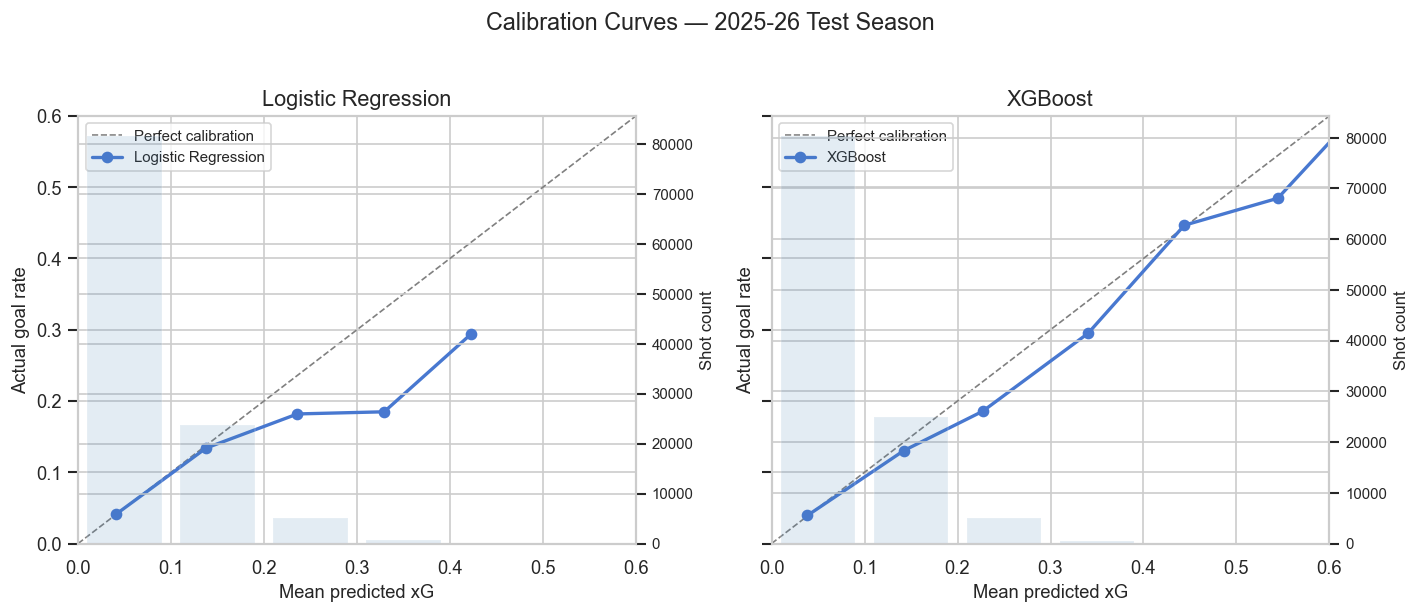

In [4]:
lr_cal  = compute_calibration(y_test, lr_proba)
xgb_cal = compute_calibration(y_test, xgb_proba)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, cal_df, label in zip(axes, [lr_cal, xgb_cal], ["Logistic Regression", "XGBoost"]):
    # Perfect calibration reference line
    ax.plot([0, 1], [0, 1], linestyle="--", color="grey", linewidth=1, label="Perfect calibration")

    # Model calibration
    ax.plot(
        cal_df["predicted_mean"],
        cal_df["actual_rate"],
        marker="o",
        linewidth=2,
        label=label,
    )

    # Shot count per bin as bar chart on secondary axis
    ax2 = ax.twinx()
    ax2.bar(
        cal_df["bin_mid"],
        cal_df["count"],
        width=0.08,
        alpha=0.15,
        color="steelblue",
        label="Shot count",
    )
    ax2.set_ylabel("Shot count", fontsize=10)
    ax2.tick_params(labelsize=9)

    ax.set_xlim(0, 0.6)
    ax.set_ylim(0, 0.6)
    ax.set_xlabel("Mean predicted xG", fontsize=11)
    ax.set_ylabel("Actual goal rate", fontsize=11)
    ax.set_title(label, fontsize=13)
    ax.legend(fontsize=9)

plt.suptitle("Calibration Curves — 2025-26 Test Season", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("notebooks/calibration_curves.png", bbox_inches="tight")
plt.show()

## 4. Feature Importance

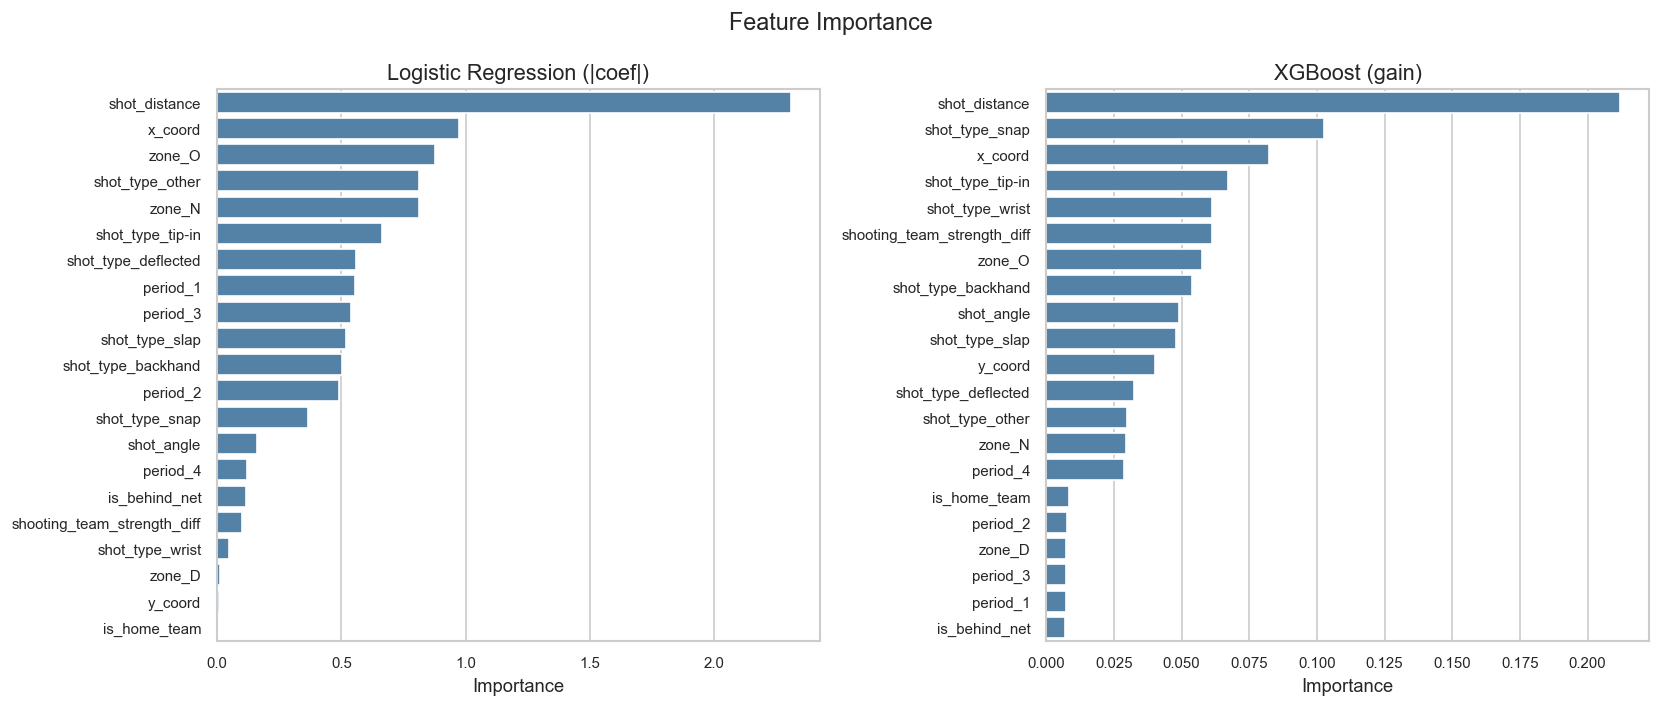

In [5]:
lr_imp  = get_feature_importance(lr_pipeline)
xgb_imp = get_feature_importance(xgb_pipeline)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, imp_df, label in zip(
    axes,
    [lr_imp, xgb_imp],
    ["Logistic Regression (|coef|)", "XGBoost (gain)"],
):
    sns.barplot(
        data=imp_df,
        x="importance",
        y="feature",
        ax=ax,
        color="steelblue",
    )
    ax.set_title(label, fontsize=13)
    ax.set_xlabel("Importance", fontsize=11)
    ax.set_ylabel("")
    ax.tick_params(labelsize=9)

plt.suptitle("Feature Importance", fontsize=14)
plt.tight_layout()
plt.savefig("notebooks/feature_importance.png", bbox_inches="tight")
plt.show()

## 5. Score Distribution

Sanity check on predicted xG values. Expected shape: heavily right-skewed with most shots
below 0.15 xG and a long tail toward higher values. Goals should skew toward higher xG than non-goals.

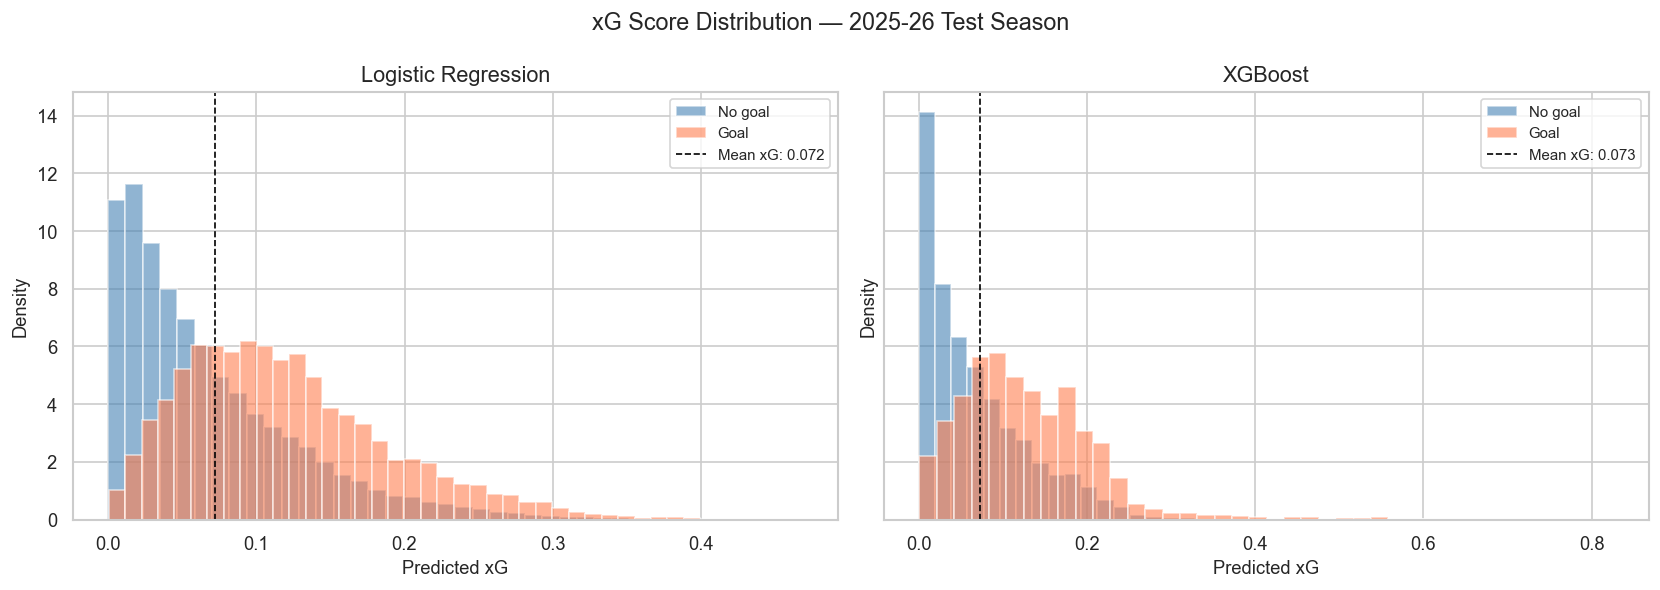

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, proba, label in zip(
    axes,
    [lr_proba, xgb_proba],
    ["Logistic Regression", "XGBoost"],
):
    # Separate goals and non-goals
    goal_mask = y_test == 1

    ax.hist(
        proba[~goal_mask],
        bins=40,
        alpha=0.6,
        density=True,
        label="No goal",
        color="steelblue",
    )
    ax.hist(
        proba[goal_mask],
        bins=40,
        alpha=0.6,
        density=True,
        label="Goal",
        color="coral",
    )

    ax.axvline(
        proba.mean(),
        color="black",
        linestyle="--",
        linewidth=1,
        label=f"Mean xG: {proba.mean():.3f}",
    )

    ax.set_xlabel("Predicted xG", fontsize=11)
    ax.set_ylabel("Density", fontsize=11)
    ax.set_title(label, fontsize=13)
    ax.legend(fontsize=9)

plt.suptitle("xG Score Distribution — 2025-26 Test Season", fontsize=14)
plt.tight_layout()
plt.savefig("notebooks/score_distribution.png", bbox_inches="tight")
plt.show()

## 6. Save Metrics

Save metrics for display in streamlit app.

In [7]:
save_metrics(
    metrics_by_model={
        "logistic_regression": compute_metrics(y_test, lr_proba),
        "xgboost": compute_metrics(y_test, xgb_proba),
    },
    calibration_by_model={
        "logistic_regression": compute_calibration(y_test, lr_proba),
        "xgboost": compute_calibration(y_test, xgb_proba),
    },
    feature_importance_by_model={
        "logistic_regression": get_feature_importance(lr_pipeline),
        "xgboost": get_feature_importance(xgb_pipeline),
        # LR feature importance omitted unless you have an equivalent for it
    },
)